In [294]:
import torch
import torchvision
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import random
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns

In [295]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [296]:
set_seed(42)

In [297]:
# alternative
x_train = torch.rand(100)
x_train = x_train * 20.0 - 10.0

In [298]:
x = torch.empty(20000).uniform_(-10,10)
## add dimensionality
x = x.unsqueeze(1)
y = torch.empty(20000).uniform_(-10,10)
y = y.unsqueeze(1)

In [300]:
function = torch.sin(x+2*y)*torch.exp(-(2*x+y)**2)

In [301]:
function.shape

torch.Size([20000, 1])

In [302]:
samples = torch.cat((x,y),dim=1)
#if x,y 1 dimension then
#samples = torch.stack((x, y), dim=0)

In [303]:
X_train, X_test, y_train, y_test = train_test_split(samples, function, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [308]:
set_seed(42)

In [309]:
class FuncAppr(nn.Module):
    def __init__(self,n_hidden_neurons):
        super(FuncAppr,self).__init__()
        self.fc1 = nn.Linear(2,n_hidden_neurons)
        self.act1 = nn.ReLU()
        self.fc2 = nn.Linear(n_hidden_neurons,n_hidden_neurons)
        self.act2 = nn.ReLU()
        self.fc3 = nn.Linear(n_hidden_neurons,n_hidden_neurons)
        self.act3 = nn.ReLU()
        self.fc4 = nn.Linear(n_hidden_neurons,1)
        
    def forward(self,x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.fc2(x)
        x = self.act2(x)
        x = self.fc3(x)
        x = self.act3(x)
        x = self.fc4(x)
        return x

In [310]:
model = FuncAppr(25)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

In [311]:
for epoch in range(15000):
    y_pred = model(X_train)
    loss = criterion(y_pred,y_train)
    loss.backward()
    
    optimizer.step()

    optimizer.zero_grad()

    if (epoch+1)%1000==0:
        print(f'epoch: {epoch+1}, loss = {loss.item():.5f}')

epoch: 1000, loss = 0.00770
epoch: 2000, loss = 0.00364
epoch: 3000, loss = 0.00080
epoch: 4000, loss = 0.00042
epoch: 5000, loss = 0.00033
epoch: 6000, loss = 0.00029
epoch: 7000, loss = 0.00026
epoch: 8000, loss = 0.00025
epoch: 9000, loss = 0.00024
epoch: 10000, loss = 0.00023
epoch: 11000, loss = 0.00022
epoch: 12000, loss = 0.00024
epoch: 13000, loss = 0.00021
epoch: 14000, loss = 0.00021
epoch: 15000, loss = 0.00020


In [290]:
## what is the loss if we every time predict just the mean value?
baseline_loss = ((y_test - y_test.mean())**2).mean()
baseline_loss

tensor(0.0170)

In [291]:
with torch.no_grad():
    y_pred = model(X_test)
    loss = criterion(y_pred,y_test)
    print(f'loss_test: {loss.item():.4f}')

loss_test: 0.0003


In [292]:
with torch.no_grad():
    y_pred = model(X_val)
    loss = criterion(y_pred,y_val)
    print(f'loss_test: {loss.item():.4f}')

loss_test: 0.0003


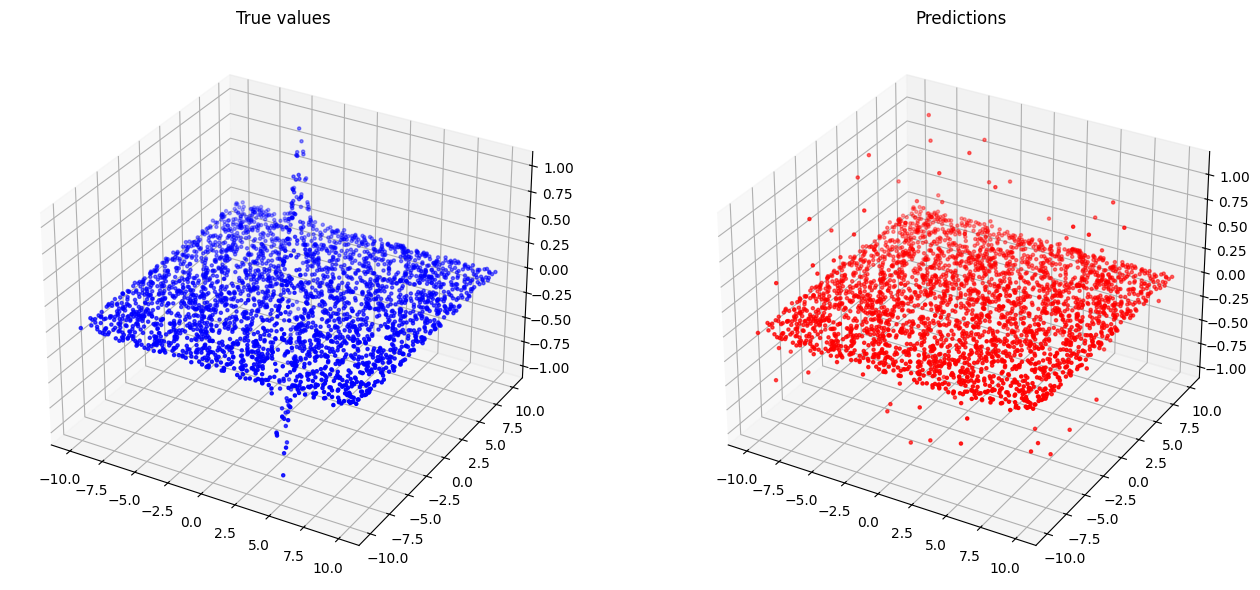

In [293]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x1 = X_test[:, 0]
x2 = X_test[:, 1]

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(x1.numpy(), x2.numpy(), y_test.squeeze().numpy(), c='blue', s=5)
ax1.set_title('True values')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(x1.numpy(), x2.numpy(), y_pred.squeeze().detach().numpy(), c='red', s=5)
ax2.set_title('Predictions')

plt.tight_layout()
plt.show()